In [ ]:
import pandas as pd

df = pd.read_excel("/content/Online Retail.xlsx", engine="openpyxl")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
# Remove rows with missing product descriptions
df = df.dropna(subset=["Description"])

print("Rows after cleaning:", len(df))

Rows after cleaning: 540455


In [ ]:
# Remove cancelled orders
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

print("Rows after removing cancellations:", len(df))


Rows after removing cancellations: 531167


In [ ]:
print("Negative quantities:", (df["Quantity"] < 0).sum())
print("Zero quantities:", (df["Quantity"] == 0).sum())
print("Negative prices:", (df["UnitPrice"] < 0).sum())
print("Zero prices:", (df["UnitPrice"] == 0).sum())

Negative quantities: 474
Zero quantities: 0
Negative prices: 2
Zero prices: 1061


In [ ]:
# Remove invalid quantities and prices
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

print("Final rows:", len(df))

Final rows: 530104


In [ ]:
# Calculate revenue
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

print("Total Revenue:", df["Revenue"].sum())

Total Revenue: 10666684.544


In [ ]:
# Create a month column
df["Month"] = df["InvoiceDate"].dt.to_period("M").astype(str)

# Calculate monthly revenue
monthly_sales = df.groupby("Month")["Revenue"].sum().reset_index()

monthly_sales

,Month,Revenue
0,2010-12,823746.140
1,2011-01,691364.560
2,2011-02,523631.890
3,2011-03,717639.360
4,2011-04,537808.621
5,2011-05,770536.020
6,2011-06,761739.900
7,2011-07,719221.191
8,2011-08,759138.380
9,2011-09,1058590.172


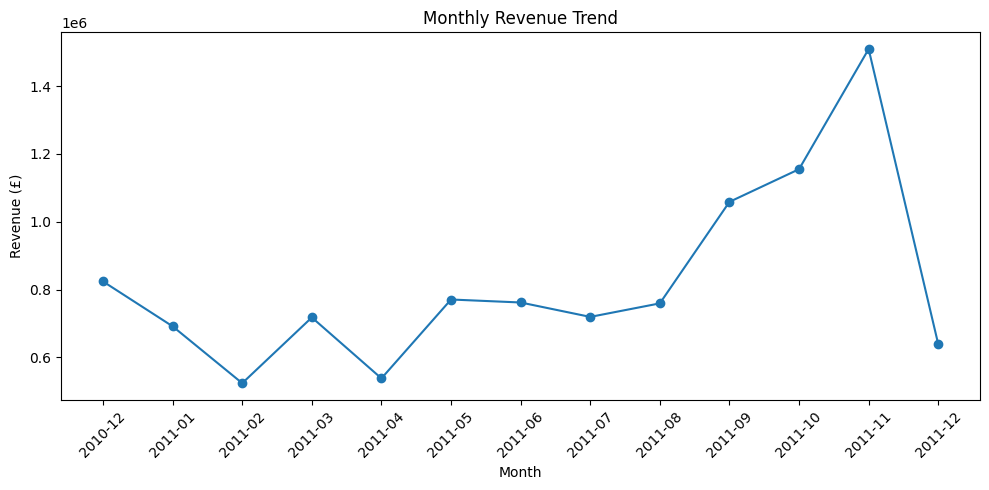

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales["Month"], monthly_sales["Revenue"], marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Top 10 products by revenue

top_products = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_products

,Description,Revenue
0,DOTCOM POSTAGE,206248.77
1,REGENCY CAKESTAND 3 TIER,174484.74
2,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3,WHITE HANGING HEART T-LIGHT HOLDER,106292.77
4,PARTY BUNTING,99504.33
5,JUMBO BAG RED RETROSPOT,94340.05
6,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
7,Manual,78112.82
8,POSTAGE,78101.88
9,RABBIT NIGHT LIGHT,66964.99


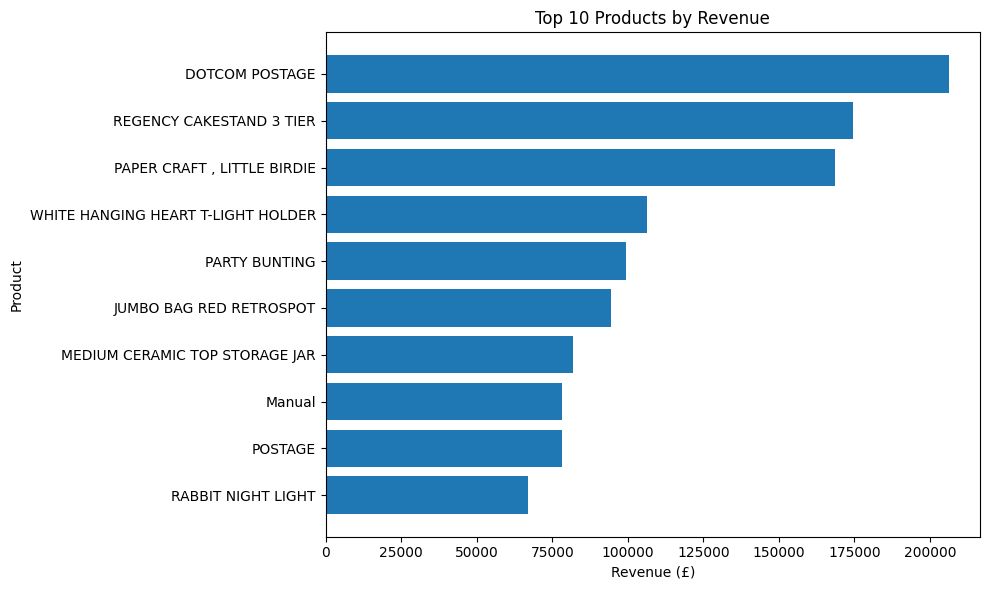

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(top_products["Description"], top_products["Revenue"])
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
country_sales = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10).reset_index()

country_sales

,Country,Revenue
0,United Kingdom,9025222.084
1,Netherlands,285446.340
2,EIRE,283453.960
3,Germany,228867.140
4,France,209715.110
5,Australia,138521.310
6,Spain,61577.110
7,Switzerland,57089.900
8,Belgium,41196.340
9,Sweden,38378.330


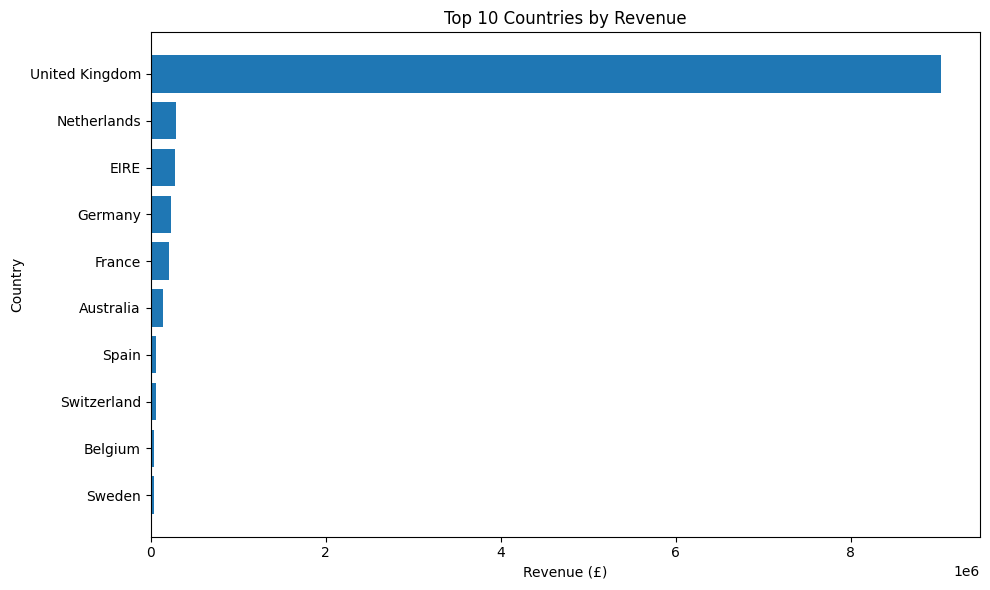

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(country_sales["Country"], country_sales["Revenue"])
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
customer_sales = df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False).head(10).reset_index()
customer_sales

,CustomerID,Revenue
0,14646.0,280206.02
1,18102.0,259657.30
2,17450.0,194550.79
3,16446.0,168472.50
4,14911.0,143825.06
5,12415.0,124914.53
6,14156.0,117379.63
7,17511.0,91062.38
8,16029.0,81024.84
9,12346.0,77183.60


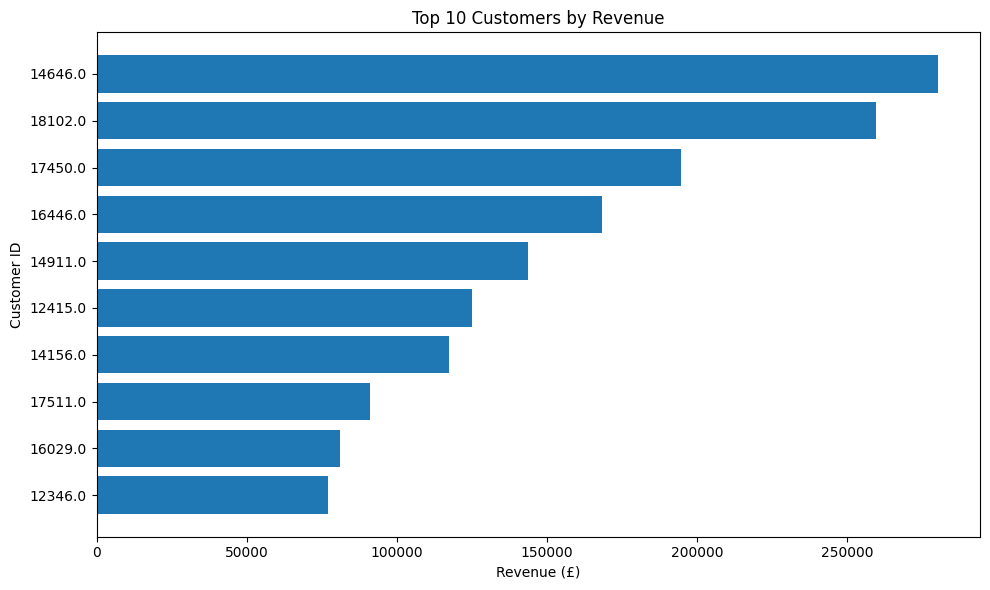

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(customer_sales["CustomerID"].astype(str), customer_sales["Revenue"])
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Customer ID")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
total_revenue = df["Revenue"].sum()
total_orders = df["InvoiceNo"].nunique()
total_customers = df["CustomerID"].nunique()
average_order_value = total_revenue / total_orders

print("Total Revenue: £", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value: £", round(average_order_value, 2))

Total Revenue: £ 10666684.54
Total Orders: 19960
Total Customers: 4338
Average Order Value: £ 534.4


## Key Insights

- Total revenue generated was £10.67M across 19,960 orders.
- November 2011 recorded the highest monthly revenue.
- The United Kingdom was the largest revenue-generating market.
- DOTCOM POSTAGE was the highest-revenue product.
- The top customers contributed significant revenue to overall sales.
- Average order value was £534.40.